# Day 10 — Monetizing the IC: Portfolio Construction & Signal Upgrades

Day 9's verdict: the signal is real (daily IC +0.013, NW t 3.4) but the long-only Q5 book converts
it into a beta-1.15 volatility tilt with **zero alpha** vs a vol-matched benchmark. Day 10 attacks
that directly.

**What's new vs day 9**

| Change | Why | Section |
|--------|-----|---------|
| Vol-adjusted momentum + regime features (breadth, dispersion) | Diversify away from raw-vol dependence; let the model condition on environment | 3, 4 |
| 3-seed LightGBM ensemble | Stabilize fold variance and degenerate-fold flakiness | 6 |
| **Four construction variants**: plain Q5, vol-neutral Q5, L/S Q5−Q1, beta-hedged Q5 | The core fix — extract selection alpha from the IC instead of factor tilt | 8 |
| Select/confirm fold discipline (select on pre-2018 tests, confirm on 2018–24) | Variant choice must not be fitted on the full evaluation window (H4 lesson applied) | 8 |
| Winner-only soft holdout & winner-aware live signals (short side included if L/S wins) | Consistency | 9, 11 |
| `paper_trade_harness.py` companion script | Closes the loop: consumes signal files, logs realized book returns + IC | 12 |

**Deferred (needs new data):** fundamentals & sector features (EODHD `/api/fundamentals` pull),
meta-labeling / triple-barrier labels, HK/MY universe repair. See Section 12.

Run **top-to-bottom only**. All day 9 hygiene (purge+embargo, PIT universe, per-date winsorization,
delisting haircuts, health gates) carries over unchanged.

## 1. Configuration

Day 9 config plus: `ENSEMBLE_SEEDS` (set to `[42]` for a fast run), `VOL_BUCKETS` for the
vol-neutral variant, `SELECT_END` for the select/confirm fold split, and `LS_GROSS` sizing.

In [1]:
import json, gc, warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import spearmanr

CFG = dict(
    DATA_PATH          = 'raw_ohlcv.parquet',
    MARKET             = 'US',
    START_DATE         = '2010-01-01',
    HORIZON            = 5,
    TRAIN_WINDOW       = 504,
    TEST_WINDOW        = 252,
    PURGE              = 5,
    EMBARGO            = 5,
    MIN_TEST_DAYS      = 60,
    MIN_HISTORY        = 252,
    ALIVE_LOOKBACK     = 21,
    HOLDOUT_START      = '2025-01-01',
    MAX_ROUNDS         = 500,
    PATIENCE           = 50,
    MIN_BOOST_ROUND    = 20,
    BASE_COST_BPS      = 5.0,
    IMPACT_COEFF       = 0.1,
    N_TRANCHES         = 5,
    PORTFOLIO_AUM      = 1_000_000,
    DELIST_RETURN      = -0.30,
    MAX_STALENESS_DAYS = 7,
    SEED               = 42,
    # day 10 additions
    ENSEMBLE_SEEDS     = [42, 7, 2026],   # [42] for a quick run
    VOL_BUCKETS        = 3,               # terciles for vol-neutral ranking
    SELECT_END         = '2018-01-01',    # variant selection uses folds testing before this
    LS_GROSS           = 1.0,             # gross per side for the L/S variant
    BETA_WINDOW        = 126,             # rolling beta for the hedged variant
)

LGB_PARAMS = {
    'objective': 'regression', 'metric': 'mae', 'num_leaves': 31,
    'learning_rate': 0.05, 'feature_fraction': 0.7, 'bagging_fraction': 0.7,
    'bagging_freq': 1, 'min_child_samples': 100, 'reg_alpha': 0.1,
    'reg_lambda': 0.1, 'verbose': -1, 'n_jobs': -1, 'seed': CFG['SEED'],
}

MARKET_FILTERS = {
    'US':  lambda t: not t.endswith('.HK') and not t.endswith('.KLSE'),
    'HK':  lambda t: t.endswith('.HK'),
    'MY':  lambda t: t.endswith('.KLSE'),
    'ALL': lambda t: True,
}

np.random.seed(CFG['SEED'])
RUN_TS = pd.Timestamp.now()
print(f"Run: {RUN_TS:%Y-%m-%d %H:%M} | python {sys.version.split()[0]} | "
      f"pandas {pd.__version__} | numpy {np.__version__} | lightgbm {lgb.__version__}")
print(f"Ensemble seeds: {CFG['ENSEMBLE_SEEDS']} | select folds end: {CFG['SELECT_END']}")

Run: 2026-07-17 06:51 | python 3.13.14 | pandas 2.3.3 | numpy 2.4.6 | lightgbm 4.6.0
Ensemble seeds: [42, 7, 2026] | select folds end: 2018-01-01


## 2. Data load & quality gate

Identical to day 9: hard failures raise; staleness, extreme moves, and adjustment events are
reported into `DQ`; row-level liquidity filters are point-in-time; the `delisted` flag is kept
for the backtest haircut.

In [2]:
df_raw = pd.read_parquet(CFG['DATA_PATH'])
if 'date' in df_raw.columns:
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    df_raw = df_raw.set_index(['date', 'ticker']).sort_index()

DQ = {'run': str(RUN_TS), 'hard_failures': [], 'warnings': []}

required = {'open', 'high', 'low', 'close', 'adjusted_close', 'volume'}
missing = required - set(df_raw.columns)
if missing:
    DQ['hard_failures'].append(f'missing columns: {missing}')
ndup = df_raw.index.duplicated().sum()
if ndup:
    DQ['hard_failures'].append(f'{ndup} duplicate (date,ticker) rows')
if DQ['hard_failures']:
    raise ValueError(f"Data quality hard failure: {DQ['hard_failures']}")

dates_all_raw = df_raw.index.get_level_values('date')
DQ['rows'] = len(df_raw)
DQ['tickers'] = df_raw.index.get_level_values('ticker').nunique()
DQ['date_min'] = str(dates_all_raw.min().date())
DQ['date_max'] = str(dates_all_raw.max().date())
DQ['staleness_days'] = int((RUN_TS.normalize() - dates_all_raw.max()).days)
if DQ['staleness_days'] > CFG['MAX_STALENESS_DAYS']:
    DQ['warnings'].append(f"DATA IS {DQ['staleness_days']} DAYS STALE (max {CFG['MAX_STALENESS_DAYS']}) — refresh before paper trading")

if 'delisted' in df_raw.columns:
    DELISTED_MAP = df_raw.groupby(level='ticker')['delisted'].last()
    DQ['delisted_tickers'] = int(DELISTED_MAP.sum())
else:
    DELISTED_MAP = pd.Series(dtype=bool)
    DQ['warnings'].append('no delisted flag in data — delisting haircut applied to every dead series')

n_bad_px = int((df_raw['adjusted_close'] <= 0).sum())
DQ['nonpositive_price_rows'] = n_bad_px
if n_bad_px:
    DQ['warnings'].append(f'{n_bad_px} rows with nonpositive prices (excluded by clean filter)')
adj_ret = (df_raw['adjusted_close'].where(df_raw['adjusted_close'] > 0)
           .groupby(level='ticker').pct_change(fill_method=None))
extreme = adj_ret[adj_ret.abs() > 0.50]
DQ['extreme_moves_gt50pct'] = int(len(extreme))
if len(extreme):
    DQ['warnings'].append(f'{len(extreme)} daily moves >|50%| — verify splits/corporate actions')

print(f"Rows {DQ['rows']:,} | tickers {DQ['tickers']} | {DQ['date_min']} → {DQ['date_max']} | "
      f"delisted tickers included: {DQ.get('delisted_tickers', 'n/a')}")
for w in DQ['warnings']:
    print(f"  ⚠ {w}")

df_clean = df_raw.loc[
    (df_raw['close'] > 1.0) &
    (df_raw['adjusted_close'] > 0) &
    (df_raw['adjusted_close'] < 999999) &
    (df_raw['volume'] > 500000) &
    (df_raw['close'] * df_raw['volume'] > 1_000_000)
].copy()
print(f"Clean: {len(df_clean):,} rows, {df_clean.index.get_level_values('ticker').nunique()} tickers")
del df_raw, adj_ret
gc.collect()

Rows 4,247,552 | tickers 1055 | 1962-01-02 → 2026-06-26 | delisted tickers included: 752
  ⚠ DATA IS 21 DAYS STALE (max 7) — refresh before paper trading
  ⚠ 2514 rows with nonpositive prices (excluded by clean filter)
  ⚠ 7554 daily moves >|50%| — verify splits/corporate actions
Clean: 2,133,522 rows, 879 tickers


20

## 3. Feature engineering (causal only)

Day 9 features plus **vol-adjusted momentum** (`ret_21d/vol_21d`, `ret_63d/vol_63d` — a Sharpe-like
momentum that is *not* mechanically long volatility). All causal; the target may be `NaN` on the
last `HORIZON` days (rows kept for scoring/backtests).

In [3]:
def compute_features(g):
    c = g['adjusted_close']; v = g['volume']; h = g['high']; l = g['low']
    out = pd.DataFrame(index=g.index)

    out['ret_1d']     = c.pct_change(1, fill_method=None)
    out['log_ret_1d'] = np.log(c / c.shift(1))
    out['ret_5d']     = c.pct_change(5, fill_method=None)
    out['ret_10d']    = c.pct_change(10, fill_method=None)
    out['ret_21d']    = c.pct_change(21, fill_method=None)
    out['ret_63d']    = c.pct_change(63, fill_method=None)

    delta = c.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    out['rsi_14'] = 100 - 100 / (1 + gain / loss.replace(0, np.nan))

    sma50, sma200 = c.rolling(50).mean(), c.rolling(200).mean()
    out['close_vs_sma50']  = c / sma50 - 1
    out['close_vs_sma200'] = c / sma200 - 1

    lr = np.log(c / c.shift(1))
    out['vol_10d'] = lr.rolling(10).std()
    out['vol_21d'] = lr.rolling(21).std()
    out['vol_63d'] = lr.rolling(63).std()

    tr = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
    out['atr_pct'] = tr.rolling(14).mean() / c

    sma20, std20 = c.rolling(20).mean(), c.rolling(20).std()
    upper, lower = sma20 + 2 * std20, sma20 - 2 * std20
    out['bb_width']    = (upper - lower) / sma20.replace(0, np.nan)
    out['bb_position'] = (c - lower) / (upper - lower).replace(0, np.nan)

    vol_sma20, vol_sma5 = v.rolling(20).mean(), v.rolling(5).mean()
    out['vol_ratio'] = v / vol_sma20.replace(0, np.nan)
    out['vol_mom']   = vol_sma5.pct_change(20, fill_method=None)

    amihud_raw = out['ret_1d'].abs() / (c * v).replace(0, np.nan)
    out['amihud'] = np.log10(amihud_raw.rolling(21).mean().clip(lower=1e-12))

    # day 10: vol-adjusted momentum (annualization cancels in the cross-section)
    out['sharpe_mom_21'] = out['ret_21d'] / (out['vol_21d'] * np.sqrt(21)).replace(0, np.nan)
    out['sharpe_mom_63'] = out['ret_63d'] / (out['vol_63d'] * np.sqrt(63)).replace(0, np.nan)

    out['target_5d'] = c.shift(-CFG['HORIZON']) / c - 1
    return out

BASE_FEATURES = [
    'ret_1d', 'log_ret_1d', 'ret_5d', 'ret_10d', 'ret_21d', 'ret_63d',
    'rsi_14', 'close_vs_sma50', 'close_vs_sma200',
    'vol_10d', 'vol_21d', 'vol_63d', 'atr_pct',
    'bb_width', 'bb_position', 'vol_ratio', 'vol_mom', 'amihud',
    'sharpe_mom_21', 'sharpe_mom_63',
]

df_features = (df_clean.groupby('ticker', group_keys=False).apply(compute_features)
               .dropna(subset=BASE_FEATURES))
print(f"Features: {df_features.shape} | unlabeled rows kept: {df_features['target_5d'].isna().sum():,}")

Features: (1990505, 21) | unlabeled rows kept: 3,193


## 4. Cross-sectional transforms & regime features (point-in-time)

Per-date winsorization and ranks as in day 9, plus two **date-level regime features** every stock
shares on a given day: `mkt_breadth` (share of universe above its 50d SMA) and `mkt_dispersion`
(cross-sectional std of 21d returns). Same-day cross-sectional aggregates — point-in-time by
construction. They give the trees something to split on when deciding *whether* momentum or
reversal logic applies.

In [4]:
WINSOR_COLS = BASE_FEATURES
grp = df_features.groupby(level='date')[WINSOR_COLS]
ql = grp.transform(lambda x: x.quantile(0.01))
qh = grp.transform(lambda x: x.quantile(0.99))
df_features[WINSOR_COLS] = df_features[WINSOR_COLS].clip(lower=ql, upper=qh)
del ql, qh
gc.collect()

for name, src in [('ret_21d_rank', 'ret_21d'), ('vol_21d_rank', 'vol_21d'),
                  ('ret_63d_rank', 'ret_63d'), ('vol_63d_rank', 'vol_63d')]:
    df_features[name] = df_features.groupby(level='date')[src].rank(pct=True)

# regime features (same value for all names on a date)
by_date = df_features.groupby(level='date')
breadth = by_date['close_vs_sma50'].apply(lambda x: (x > 0).mean())
dispersion = by_date['ret_21d'].std()
didx = df_features.index.get_level_values('date')
df_features['mkt_breadth'] = breadth.reindex(didx).values
df_features['mkt_dispersion'] = dispersion.reindex(didx).values

FEATURE_COLS = BASE_FEATURES + ['ret_21d_rank', 'vol_21d_rank', 'ret_63d_rank', 'vol_63d_rank',
                                'mkt_breadth', 'mkt_dispersion']
TARGET_COL, RAW_TARGET = 'target_5d_rank', 'target_5d'

print(f"{len(FEATURE_COLS)} features | NaN in features: "
      f"{df_features[FEATURE_COLS].isna().sum().sum()}")

26 features | NaN in features: 598


## 5. Universe & walk-forward folds

Identical construction to day 9 (PIT universe, purge+embargo, truncated final fold). New: folds
are tagged **SELECT** (test ends before `SELECT_END`) or **CONFIRM** — the construction variant
is chosen on SELECT folds only and judged on CONFIRM folds (Section 8).

In [5]:
keep_fn = MARKET_FILTERS[CFG['MARKET']]
mkt_tickers = [t for t in df_features.index.get_level_values('ticker').unique() if keep_fn(t)]

prices_all = (df_clean['adjusted_close'].unstack('ticker')
              .loc['2009-01-01':, mkt_tickers].sort_index())
dollar_vol = (df_clean['close'] * df_clean['volume']).unstack('ticker') \
             .reindex(columns=prices_all.columns)
adv_lag = dollar_vol.rolling(20, min_periods=5).mean().shift(1)
ret_all = prices_all.pct_change(fill_method=None)
vol_lag = ret_all.rolling(20, min_periods=5).std().shift(1)
del dollar_vol, df_clean
gc.collect()

mask = ((df_features.index.get_level_values('date') >= CFG['START_DATE']) &
        (df_features.index.get_level_values('ticker').isin(set(mkt_tickers))))
df_ml = df_features.loc[mask].copy()
del df_features
gc.collect()

df_ml[TARGET_COL] = df_ml.groupby(level='date')[RAW_TARGET].rank(pct=True)

DATE_LV = df_ml.index.get_level_values('date')
TICK_LV = df_ml.index.get_level_values('ticker')
dates = DATE_LV.unique().sort_values()

def fold_universe(train_start, train_end, entry_date=None):
    win = prices_all.loc[train_start:train_end]
    cov = win.notna().sum()
    uni = set(cov[cov >= CFG['MIN_HISTORY']].index)
    if entry_date is not None:
        hist = prices_all.loc[:entry_date]
        if len(hist) and hist.index[-1] == entry_date:
            hist = hist.iloc[:-1]
        recent = hist.iloc[-CFG['ALIVE_LOOKBACK']:]
        uni &= set(recent.columns[recent.notna().any()])
    return uni

def make_folds(dts, train_w, test_w, gap, min_test):
    folds, fid, i = [], 0, train_w + gap
    while i < len(dts):
        te_end = min(i + test_w - 1, len(dts) - 1)
        if te_end - i + 1 < min_test:
            break
        folds.append(dict(fold=fid,
                          train_start=dts[i - gap - train_w], train_end=dts[i - gap - 1],
                          test_start=dts[i], test_end=dts[te_end]))
        fid += 1
        i += test_w
    return folds

GAP = CFG['PURGE'] + CFG['EMBARGO']
wf_dates = dates[dates < CFG['HOLDOUT_START']]
folds = make_folds(wf_dates, CFG['TRAIN_WINDOW'], CFG['TEST_WINDOW'], GAP, CFG['MIN_TEST_DAYS'])
for f in folds:
    f['role'] = 'SELECT' if f['test_end'] < pd.Timestamp(CFG['SELECT_END']) else 'CONFIRM'

n_sel = sum(f['role'] == 'SELECT' for f in folds)
print(f"Market {CFG['MARKET']}: {len(mkt_tickers)} tickers | ML rows {len(df_ml):,} | "
      f"folds: {len(folds)} ({n_sel} SELECT / {len(folds)-n_sel} CONFIRM)")
ft = pd.DataFrame(folds)
for c in ['train_start', 'train_end', 'test_start', 'test_end']:
    ft[c] = ft[c].dt.strftime('%Y-%m-%d')
print(ft[['fold', 'train_start', 'train_end', 'test_start', 'test_end', 'role']].to_string(index=False))

Market US: 235 tickers | ML rows 745,465 | folds: 13 (5 SELECT / 8 CONFIRM)
 fold train_start  train_end test_start   test_end    role
    0  2010-01-04 2011-12-30 2012-01-18 2013-01-17  SELECT
    1  2011-01-03 2013-01-03 2013-01-18 2014-01-17  SELECT
    2  2012-01-03 2014-01-03 2014-01-21 2015-01-20  SELECT
    3  2013-01-04 2015-01-05 2015-01-21 2016-01-20  SELECT
    4  2014-01-06 2016-01-05 2016-01-21 2017-01-19  SELECT
    5  2015-01-06 2017-01-04 2017-01-20 2018-01-19 CONFIRM
    6  2016-01-06 2018-01-04 2018-01-22 2019-01-22 CONFIRM
    7  2017-01-05 2019-01-07 2019-01-23 2020-01-22 CONFIRM
    8  2018-01-05 2020-01-07 2020-01-23 2021-01-21 CONFIRM
    9  2019-01-08 2021-01-06 2021-01-22 2022-01-20 CONFIRM
   10  2020-01-08 2022-01-05 2022-01-21 2023-01-23 CONFIRM
   11  2021-01-07 2023-01-06 2023-01-24 2024-01-24 CONFIRM
   12  2022-01-06 2024-01-09 2024-01-25 2024-12-31 CONFIRM


## 6. Walk-forward training — seed ensemble

Same purged fit/val and `MIN_BOOST_ROUND` floor as day 9, but each fold trains
`len(ENSEMBLE_SEEDS)` models and averages their predictions. A fold is flagged degenerate only
if **every** seed hits the floor. Predictions carry `vol_63d` so Section 8 can build
vol-neutral memberships without touching `df_ml` again.

In [6]:
def purged_fit_val(train_df):
    tdates = train_df.index.get_level_values('date').unique().sort_values()
    v0 = int(len(tdates) * 0.8)
    val_start  = tdates[v0]
    purge_cut  = tdates[max(0, v0 - CFG['PURGE'])]
    fit_df = train_df[train_df.index.get_level_values('date') < purge_cut]
    val_df = train_df[train_df.index.get_level_values('date') >= val_start]
    return fit_df, val_df

def train_model(fit_df, val_df, seed):
    params = dict(LGB_PARAMS, seed=seed)
    dtrain = lgb.Dataset(fit_df[FEATURE_COLS], label=fit_df[TARGET_COL])
    dval   = lgb.Dataset(val_df[FEATURE_COLS], label=val_df[TARGET_COL], reference=dtrain)
    model = lgb.train(params, dtrain, num_boost_round=CFG['MAX_ROUNDS'],
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(CFG['PATIENCE'], verbose=False),
                                 lgb.log_evaluation(0)])
    degenerate = model.best_iteration < CFG['MIN_BOOST_ROUND']
    if degenerate:
        model = lgb.train(params, dtrain, num_boost_round=CFG['MIN_BOOST_ROUND'],
                          callbacks=[lgb.log_evaluation(0)])
    return model, model.num_trees(), degenerate

def train_ensemble(train_df, X_test):
    fit_df, val_df = purged_fit_val(train_df)
    preds, trees, degens, models = [], [], [], []
    for seed in CFG['ENSEMBLE_SEEDS']:
        m, n, d = train_model(fit_df, val_df, seed)
        preds.append(m.predict(X_test))
        trees.append(n); degens.append(d); models.append(m)
    return np.mean(preds, axis=0), int(np.mean(trees)), all(degens), models

def daily_ic_series(df, min_names=10):
    lab = df.dropna(subset=['y_true'])
    ic = lab.groupby(level='date').apply(
        lambda g: spearmanr(g['y_pred'], g['y_true'])[0] if len(g) > min_names else np.nan)
    return ic.dropna()

oos_parts, fold_rows, imp_parts = [], [], []
for f in folds:
    uni = fold_universe(f['train_start'], f['train_end'], f['test_start'])
    tr_m = (DATE_LV >= f['train_start']) & (DATE_LV <= f['train_end']) & TICK_LV.isin(uni)
    te_m = (DATE_LV >= f['test_start'])  & (DATE_LV <= f['test_end'])  & TICK_LV.isin(uni)

    train_df = df_ml.loc[tr_m].dropna(subset=[TARGET_COL])
    test_df  = df_ml.loc[te_m]

    y_pred, n_trees, degen, models = train_ensemble(train_df, test_df[FEATURE_COLS])

    pred = pd.DataFrame({'y_pred': y_pred, 'y_true': test_df[RAW_TARGET].values,
                         'vol_63d': test_df['vol_63d'].values,
                         'fold': f['fold']}, index=test_df.index)
    oos_parts.append(pred)

    dic = daily_ic_series(pred)
    fold_rows.append(dict(fold=f['fold'], role=f['role'],
                          test_start=f['test_start'].strftime('%Y-%m-%d'),
                          test_end=f['test_end'].strftime('%Y-%m-%d'),
                          n_test=len(test_df), n_tickers=len(uni),
                          ic=dic.mean(), trees=n_trees, degen=degen))
    imp_parts.append(pd.DataFrame({'feature': FEATURE_COLS,
                                   'importance': np.mean([m.feature_importance('gain') for m in models], axis=0),
                                   'fold': f['fold']}))
    print(f"Fold {f['fold']:>2d} [{f['role']:7s}] | daily IC {dic.mean():+.4f} | trees {n_trees:>3d}"
          f"{' DEGEN' if degen else '      '} | univ {len(uni):>3d} | "
          f"{f['test_start']:%Y-%m-%d} → {f['test_end']:%Y-%m-%d}")

df_oos = pd.concat(oos_parts).sort_index()
df_fold = pd.DataFrame(fold_rows)
df_imp = pd.concat(imp_parts)
print(f"\nOOS predictions: {len(df_oos):,} rows | degenerate folds (all seeds): "
      f"{int(df_fold['degen'].sum())}/{len(df_fold)}")

Fold  0 [SELECT ] | daily IC +0.0210 | trees  37       | univ 171 | 2012-01-18 → 2013-01-17
Fold  1 [SELECT ] | daily IC +0.0340 | trees  32       | univ 171 | 2013-01-18 → 2014-01-17
Fold  2 [SELECT ] | daily IC +0.0019 | trees  20       | univ 171 | 2014-01-21 → 2015-01-20
Fold  3 [SELECT ] | daily IC -0.0337 | trees  20 DEGEN | univ 173 | 2015-01-21 → 2016-01-20
Fold  4 [SELECT ] | daily IC +0.0001 | trees  20       | univ 181 | 2016-01-21 → 2017-01-19
Fold  5 [CONFIRM] | daily IC +0.0019 | trees  22       | univ 186 | 2017-01-20 → 2018-01-19
Fold  6 [CONFIRM] | daily IC +0.0135 | trees  22       | univ 181 | 2018-01-22 → 2019-01-22
Fold  7 [CONFIRM] | daily IC +0.0293 | trees  33       | univ 183 | 2019-01-23 → 2020-01-22
Fold  8 [CONFIRM] | daily IC +0.0447 | trees  20 DEGEN | univ 181 | 2020-01-23 → 2021-01-21
Fold  9 [CONFIRM] | daily IC -0.0043 | trees  20 DEGEN | univ 185 | 2021-01-22 → 2022-01-20
Fold 10 [CONFIRM] | daily IC -0.0095 | trees  20 DEGEN | univ 186 | 2022-01-21 →

## 7. Signal evaluation

Per-date IC with Newey–West t (primary), per-fold table, per-date quintile means, and feature
importance — watch whether `sharpe_mom_*` and the regime features displace raw `vol_63d`.

 fold    role test_start   test_end  n_test  n_tickers        ic  trees  degen
    0  SELECT 2012-01-18 2013-01-17   41191        171  0.021012     37  False
    1  SELECT 2013-01-18 2014-01-17   40822        171  0.034036     32  False
    2  SELECT 2014-01-21 2015-01-20   41510        171  0.001937     20  False
    3  SELECT 2015-01-21 2016-01-20   42402        173 -0.033711     20   True
    4  SELECT 2016-01-21 2017-01-19   43794        181  0.000075     20  False
    5 CONFIRM 2017-01-20 2018-01-19   44002        186  0.001913     22  False
    6 CONFIRM 2018-01-22 2019-01-22   44316        181  0.013547     22  False
    7 CONFIRM 2019-01-23 2020-01-22   43613        183  0.029281     33  False
    8 CONFIRM 2020-01-23 2021-01-21   43920        181  0.044651     20   True
    9 CONFIRM 2021-01-22 2022-01-20   43787        185 -0.004273     20   True
   10 CONFIRM 2022-01-21 2023-01-23   45399        186 -0.009502     20   True
   11 CONFIRM 2023-01-24 2024-01-24   44709        1

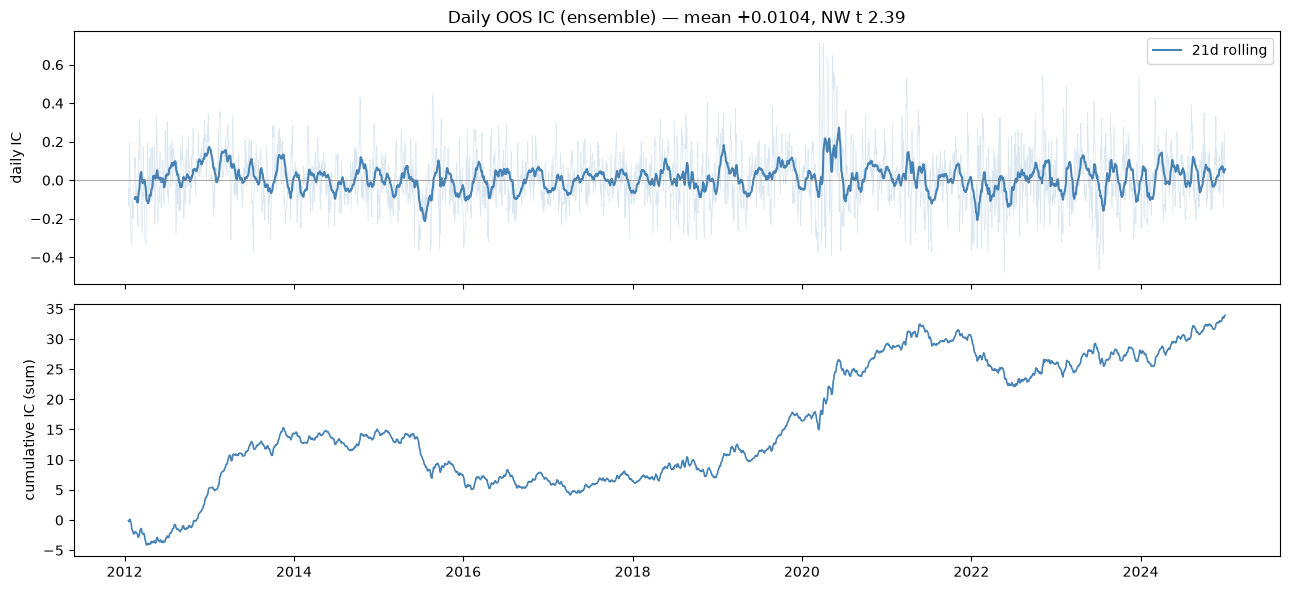

Mean 5D fwd return (%) by predicted quintile: {1: 0.3666, 2: 0.3426, 3: 0.3708, 4: 0.371, 5: 0.5338}


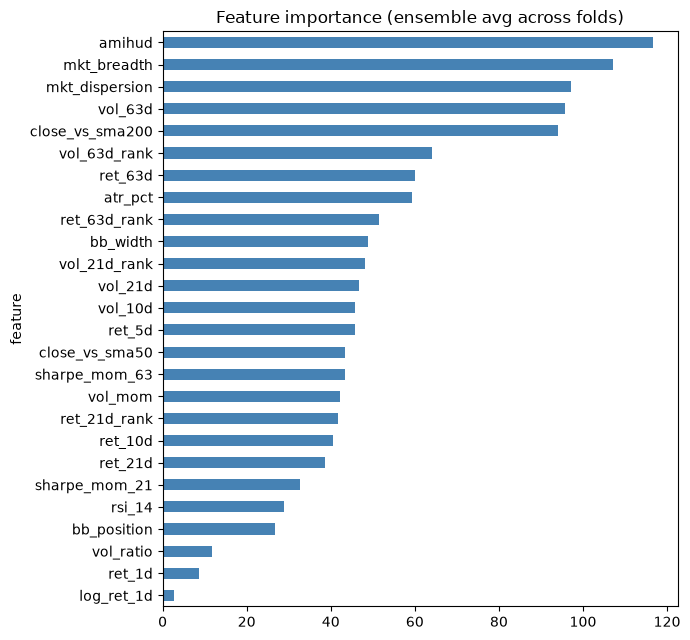

In [7]:
def nw_tstat(x, lags):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n, m = len(x), x.mean()
    e = x - m
    s = e @ e / n
    for l in range(1, lags + 1):
        s += 2 * (1 - l / (lags + 1)) * (e[:-l] @ e[l:]) / n
    return m / np.sqrt(s / n)

daily_ic = daily_ic_series(df_oos)
nw_t = nw_tstat(daily_ic, CFG['HORIZON'] - 1)
print(df_fold.to_string(index=False))
print(f"\nDaily IC: mean {daily_ic.mean():+.4f} | NW t {nw_t:.2f} | days {len(daily_ic)}")

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(daily_ic.index, daily_ic, alpha=0.2, lw=0.5, color='steelblue')
axes[0].plot(daily_ic.rolling(21).mean(), lw=1.5, color='steelblue', label='21d rolling')
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].set_ylabel('daily IC')
axes[0].set_title(f'Daily OOS IC (ensemble) — mean {daily_ic.mean():+.4f}, NW t {nw_t:.2f}')
axes[0].legend()
axes[1].plot(daily_ic.cumsum(), lw=1.2, color='steelblue')
axes[1].set_ylabel('cumulative IC (sum)')
plt.tight_layout(); plt.show()

lab = df_oos.dropna(subset=['y_true']).copy()
lab['q'] = np.ceil(lab.groupby(level='date')['y_pred'].rank(pct=True) * 5).clip(1, 5).astype(int)
q_means = (lab.groupby([lab.index.get_level_values('date'), 'q'])['y_true']
           .mean().unstack('q').mean() * 100)
print("Mean 5D fwd return (%) by predicted quintile:", q_means.round(4).to_dict())

avg_imp = df_imp.groupby('feature')['importance'].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 6.5))
avg_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importance (ensemble avg across folds)')
plt.tight_layout(); plt.show()

## 8. Construction variants & select/confirm discipline

One generalized `tranche_backtest()` takes long (and optional short) membership per (date, ticker)
and applies identical mechanics everywhere: 5 overlapping tranches, commission + sqrt impact,
delisting haircuts, PIT costs. Variants differ **only** in membership/hedging:

| Variant | Construction | Benchmark for excess |
|---------|--------------|----------------------|
| `q5_plain` | top quintile by score (day 9 baseline) | vol-matched EW |
| `q5_volneutral` | top quintile **within each vol tercile** — vol exposure neutralized by design | vol-matched EW |
| `ls_q5q1` | long Q5, short Q1, dollar-neutral | cash (0) |
| `beta_hedged` | `q5_plain` minus rolling-beta × EW universe (hedge assumed costless — index futures) | cash (0) |

**Discipline (the H4 lesson):** the winner is picked on SELECT folds only (tests pre-`SELECT_END`),
then judged on CONFIRM folds it had no vote in. Both are shown; trust the CONFIRM column.

[q5_plain] 2012-01-18 → 2024-12-31 | delist hits 8 | avg cost 1.0 bps/d | 1-way turnover 9.6%/d
[q5_volneutral] 2012-01-18 → 2024-12-31 | delist hits 8 | avg cost 1.1 bps/d | 1-way turnover 10.2%/d
[ls_q5q1] 2012-01-18 → 2024-12-31 | delist hits 8 | avg cost 2.1 bps/d | 1-way turnover 19.9%/d
[beta_hedged] 2012-01-18 → 2024-12-31 | delist hits 8 | avg cost 1.0 bps/d | 1-way turnover 9.6%/d

Variant comparison (excess vs vol-matched EW for long-only, vs cash for neutral):
               sharpe        ann_excess        excess_ir       
window        CONFIRM SELECT    CONFIRM SELECT   CONFIRM SELECT
variant                                                        
beta_hedged     0.242  0.222      0.017  0.010     0.242  0.222
ls_q5q1         0.275 -0.027      0.037 -0.002     0.275 -0.027
q5_plain        1.076  1.181     -0.005 -0.006    -0.084 -0.130
q5_volneutral   1.101  1.261     -0.024 -0.004    -0.370 -0.079

WINNER on SELECT folds: beta_hedged (excess IR 0.22)
CONFIRM-fold verdict: 

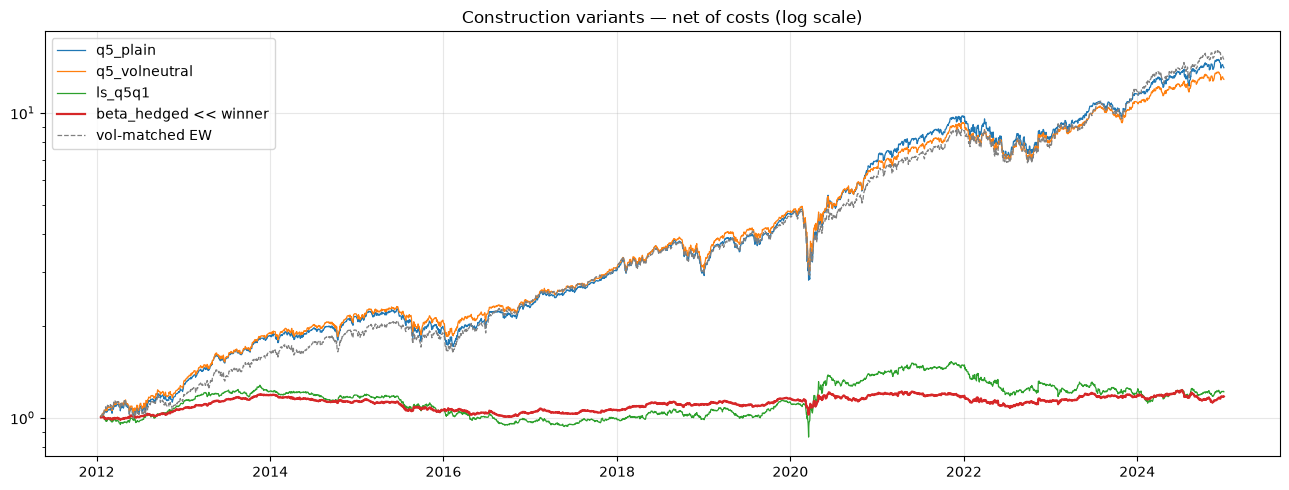

In [8]:
def perf_stats(r):
    r = r.iloc[1:].dropna()
    if len(r) < 40 or r.std() == 0:
        return dict(cagr=np.nan, vol=np.nan, sharpe=np.nan, maxdd=np.nan)
    cum = (1 + r).cumprod()
    years = len(r) / 252
    return dict(cagr=cum.iloc[-1] ** (1 / years) - 1, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252),
                maxdd=(cum / cum.cummax() - 1).min())

def weights_from_member(member, dts, cols):
    m = member.astype(float).unstack('ticker').reindex(index=dts, columns=cols).fillna(0.0)
    w = m.div(m.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    return w.rolling(CFG['N_TRANCHES'], min_periods=1).mean()

def tranche_backtest(pred_df, member_long, member_short=None, label=''):
    dts = pred_df.index.get_level_values('date').unique().sort_values()
    cols = pred_df.index.get_level_values('ticker').unique()
    W = weights_from_member(member_long, dts, cols)
    if member_short is not None:
        W = W - CFG['LS_GROSS'] * weights_from_member(member_short, dts, cols)

    px = prices_all.reindex(columns=W.columns)
    rets = px.pct_change(fill_method=None).reindex(index=dts)
    last_px = px.apply(lambda s: s.last_valid_index())
    n_delist = 0
    for tkr, ld in last_px.items():
        if ld is not None and ld < dts[-1]:
            after = dts[dts > ld]
            if len(after):
                if bool(DELISTED_MAP.get(tkr, True)):
                    rets.loc[after[0], tkr] = CFG['DELIST_RETURN']
                    n_delist += 1
                if len(after) > 1:
                    W.loc[after[1]:, tkr] = 0.0
    rets = rets.fillna(0.0)

    gross = (W.shift(1) * rets).sum(axis=1)
    tw = (W - W.shift(1).fillna(0.0)).abs()
    td = tw * CFG['PORTFOLIO_AUM']
    adv_a = adv_lag.reindex(index=dts, columns=W.columns)
    vol_a = vol_lag.reindex(index=dts, columns=W.columns).fillna(0.02)
    part = (td / adv_a.where(adv_a > 0)).clip(upper=1.0)
    part = part.where(td.le(0) | part.notna(), 1.0).fillna(0.0)
    impact = CFG['IMPACT_COEFF'] * vol_a * np.sqrt(part)
    cost = (tw * (CFG['BASE_COST_BPS'] / 10_000) + tw * impact).sum(axis=1)
    net = gross - cost

    bench_m = pred_df['y_pred'].notna().astype(float).unstack('ticker').reindex(index=dts).fillna(0.0)
    bw = bench_m.div(bench_m.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    bench = (bw.shift(1) * rets).sum(axis=1)
    vol_r = vol_lag.reindex(index=dts, columns=bench_m.columns)
    vrank = vol_r.where(bench_m > 0).rank(axis=1, pct=True)
    hv = (vrank >= 0.5).astype(float)
    hw = hv.div(hv.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    bench_vol = (hw.shift(1) * rets).sum(axis=1)
    if label:
        print(f"[{label}] {dts[0].date()} → {dts[-1].date()} | delist hits {n_delist} | "
              f"avg cost {cost.iloc[1:].mean()*1e4:.1f} bps/d | "
              f"1-way turnover {tw.sum(axis=1).mean()/2:.1%}/d")
    return dict(dates=dts, gross=gross, net=net, bench=bench, bench_vol=bench_vol,
                cost=cost, W=W, rets=rets)

def make_members(pred_df, variant):
    r = pred_df.groupby(level='date')['y_pred'].rank(pct=True)
    if variant in ('q5_plain', 'beta_hedged'):
        return r >= 0.80, None
    if variant == 'q5_volneutral':
        vb = pred_df.groupby(level='date')['vol_63d'].transform(
            lambda x: pd.qcut(x.rank(method='first'), CFG['VOL_BUCKETS'], labels=False))
        key = [pred_df.index.get_level_values('date'), vb]
        rb = pred_df.groupby(key)['y_pred'].rank(pct=True)
        rb.index = pred_df.index
        return rb >= 0.80, None
    if variant == 'ls_q5q1':
        return r >= 0.80, r <= 0.20
    raise ValueError(variant)

def variant_net(pred_df, variant, label=''):
    ml, ms = make_members(pred_df, variant)
    bt = tranche_backtest(pred_df, ml, ms, label=label)
    if variant == 'beta_hedged':
        cov = bt['net'].rolling(CFG['BETA_WINDOW']).cov(bt['bench'])
        var = bt['bench'].rolling(CFG['BETA_WINDOW']).var()
        beta_roll = (cov / var).shift(1).clip(0, 3).fillna(1.0)
        bt['net'] = bt['net'] - beta_roll * bt['bench']   # hedge leg assumed costless
    return bt

VARIANTS = ['q5_plain', 'q5_volneutral', 'ls_q5q1', 'beta_hedged']
NEUTRAL = {'ls_q5q1', 'beta_hedged'}   # benchmark = cash; long-onlys use vol-matched EW

sel_days = df_oos['fold'].map({r['fold']: r['role'] for _, r in df_fold.iterrows()})
bts, rows = {}, []
for v in VARIANTS:
    bt = variant_net(df_oos, v, label=v)
    bts[v] = bt
    excess = bt['net'] - (0 if v in NEUTRAL else bt['bench_vol'])
    roles = pd.Series(sel_days.groupby(level='date').first().reindex(bt['net'].index))
    for role in ['SELECT', 'CONFIRM']:
        msk = roles.values == role
        st = perf_stats(bt['net'][msk])
        ex = excess[msk].iloc[1:]
        ir = ex.mean() / ex.std() * np.sqrt(252) if ex.std() > 0 else np.nan
        rows.append(dict(variant=v, window=role, sharpe=st['sharpe'],
                         ann_excess=ex.mean() * 252, excess_ir=ir, maxdd=st['maxdd']))

df_var = pd.DataFrame(rows)
pivot = df_var.pivot(index='variant', columns='window',
                     values=['sharpe', 'ann_excess', 'excess_ir'])
print("\nVariant comparison (excess vs vol-matched EW for long-only, vs cash for neutral):")
print(pivot.round(3).to_string())

sel_rank = df_var[df_var['window'] == 'SELECT'].set_index('variant')['excess_ir']
if sel_rank.isna().all():
    print('\n⚠ No SELECT-window data (all folds are CONFIRM) — ranking on CONFIRM as a fallback.')
    print('  The confirmation is NOT out-of-vote in this case; treat the winner as unconfirmed.')
    sel_rank = df_var[df_var['window'] == 'CONFIRM'].set_index('variant')['excess_ir']
WINNER = sel_rank.idxmax()
conf_rows = df_var[(df_var['variant'] == WINNER) & (df_var['window'] == 'CONFIRM')]
conf = (conf_rows.iloc[0] if len(conf_rows) and not np.isnan(conf_rows.iloc[0]['excess_ir'])
        else pd.Series(dict(excess_ir=np.nan, ann_excess=np.nan, sharpe=np.nan)))
print(f"\nWINNER on SELECT folds: {WINNER} (excess IR {sel_rank.max():.2f})")
print(f"CONFIRM-fold verdict:   excess IR {conf['excess_ir']:.2f}, ann excess {conf['ann_excess']:+.2%}, "
      f"Sharpe {conf['sharpe']:.2f}")
print("If the CONFIRM excess IR is near zero or negative, no variant has proven selection alpha yet.")

fig, ax = plt.subplots(figsize=(13, 5))
for v in VARIANTS:
    cum = (1 + bts[v]['net'].iloc[1:]).cumprod()
    ax.plot(cum, lw=1.6 if v == WINNER else 0.9,
            label=f"{v}{' << winner' if v == WINNER else ''}")
ax.plot((1 + bts['q5_plain']['bench_vol'].iloc[1:]).cumprod(), color='gray', lw=0.9,
        linestyle='--', label='vol-matched EW')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Construction variants — net of costs (log scale)')
plt.tight_layout(); plt.show()

## 9. Soft holdout (2025 →) — winner only

Only the SELECT-fold winner is evaluated on the holdout, and the holdout remains **soft**
(day 8's scans touched this period). One model (ensemble), same code path.

Holdout 2025-01-02 → 2026-06-26 | trees 20 DEGEN | daily IC +0.0245 (NW t 1.11)

[holdout/beta_hedged] 2025-01-02 → 2026-06-26 | delist hits 1 | avg cost 0.8 bps/d | 1-way turnover 8.3%/d
Holdout beta_hedged: Sharpe 0.47 | ann excess +5.42% | excess IR 0.47 | maxDD -10.55%


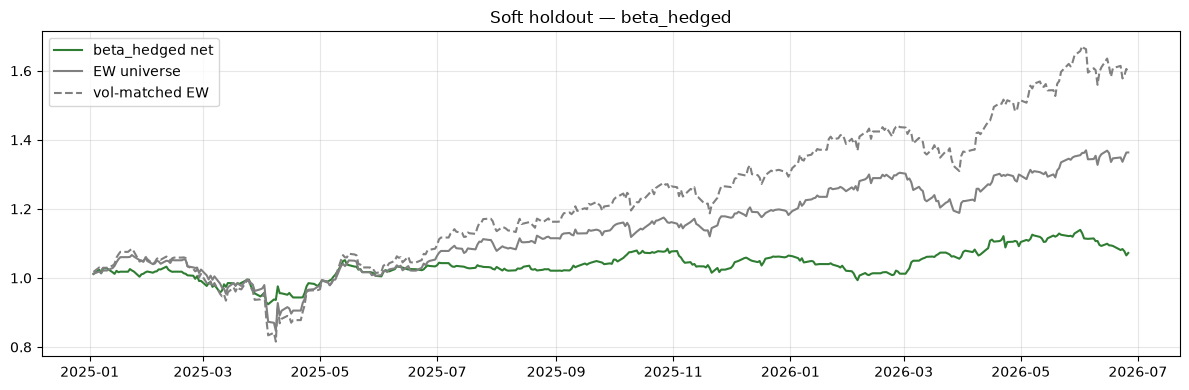

In [9]:
tail_dates = dates[dates >= CFG['HOLDOUT_START']]
ho = None
if len(tail_dates) < CFG['MIN_TEST_DAYS']:
    print(f"Only {len(tail_dates)} holdout days — skipping.")
else:
    pre = dates[dates < tail_dates[0]]
    train_dates = pre[-(CFG['TRAIN_WINDOW'] + GAP):-GAP]
    uni_h = fold_universe(train_dates[0], train_dates[-1], tail_dates[0])
    tr_m = DATE_LV.isin(train_dates) & TICK_LV.isin(uni_h)
    te_m = (DATE_LV >= tail_dates[0]) & TICK_LV.isin(uni_h)
    train_df = df_ml.loc[tr_m].dropna(subset=[TARGET_COL])
    test_df  = df_ml.loc[te_m]

    y_pred_h, trees_h, degen_h, _ = train_ensemble(train_df, test_df[FEATURE_COLS])
    ho = pd.DataFrame({'y_pred': y_pred_h, 'y_true': test_df[RAW_TARGET].values,
                       'vol_63d': test_df['vol_63d'].values}, index=test_df.index)
    dic_h = daily_ic_series(ho)
    print(f"Holdout {tail_dates[0].date()} → {tail_dates[-1].date()} | trees {trees_h}"
          f"{' DEGEN' if degen_h else ''} | daily IC {dic_h.mean():+.4f} "
          f"(NW t {nw_tstat(dic_h, CFG['HORIZON']-1):.2f})\n")

    bth = variant_net(ho, WINNER, label=f'holdout/{WINNER}')
    ex_h = (bth['net'] - (0 if WINNER in NEUTRAL else bth['bench_vol'])).iloc[1:]
    st_h = perf_stats(bth['net'])
    print(f"Holdout {WINNER}: Sharpe {st_h['sharpe']:.2f} | ann excess {ex_h.mean()*252:+.2%} | "
          f"excess IR {ex_h.mean()/ex_h.std()*np.sqrt(252):.2f} | maxDD {st_h['maxdd']:.2%}")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot((1 + bth['net'].iloc[1:]).cumprod(), color='#2E7D32', label=f'{WINNER} net')
    ax.plot((1 + bth['bench'].iloc[1:]).cumprod(), color='gray', label='EW universe')
    ax.plot((1 + bth['bench_vol'].iloc[1:]).cumprod(), color='gray', linestyle='--',
            label='vol-matched EW')
    ax.set_title(f'Soft holdout — {WINNER}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 10. Diagnostics & health checks

Day 9 gates, applied to the **winner** variant, plus a new gate: the winner's CONFIRM-fold excess
IR must be positive (selection alpha that survived out-of-vote folds). Extremes counted in held
positions only.

In [10]:
HEALTH = {}
bt_w = bts[WINNER]
excess_w = bt_w['net'] - (0 if WINNER in NEUTRAL else bt_w['bench_vol'])

HEALTH['winner'] = WINNER
HEALTH['degenerate_fold_share'] = float(df_fold['degen'].mean())
HEALTH['daily_ic_mean'] = float(daily_ic.mean())
HEALTH['daily_ic_nw_t'] = float(nw_t)
HEALTH['winner_net_sharpe'] = float(perf_stats(bt_w['net'])['sharpe'])
HEALTH['winner_select_excess_ir'] = float(sel_rank.max())
HEALTH['winner_confirm_excess_ir'] = float(conf['excess_ir'])
HEALTH['winner_confirm_ann_excess'] = float(conf['ann_excess'])

contrib = (bt_w['W'].shift(1) * bt_w['rets']).sum()
HEALTH['top10_pnl_concentration'] = float(contrib.nlargest(10).sum() / max(contrib.abs().sum(), 1e-9))
held = bt_w['W'].shift(1).abs() > 0
ext_bt = bt_w['rets'][(bt_w['rets'].abs() > 0.5) & held]
HEALTH['extreme_returns_in_backtest'] = int(ext_bt.notna().sum().sum())
HEALTH['data_staleness_days'] = DQ['staleness_days']

checks = [
    ('NW t-stat >= 2',                          HEALTH['daily_ic_nw_t'] >= 2),
    ('degenerate folds < 30%',                  HEALTH['degenerate_fold_share'] < 0.30),
    ('winner CONFIRM excess IR > 0 (alpha)',    HEALTH['winner_confirm_excess_ir'] > 0),
    ('top-10 P&L concentration < 40%',          HEALTH['top10_pnl_concentration'] < 0.40),
    ('no unverified extremes in HELD names',    HEALTH['extreme_returns_in_backtest'] == 0),
    (f"data fresh (<= {CFG['MAX_STALENESS_DAYS']}d)", HEALTH['data_staleness_days'] <= CFG['MAX_STALENESS_DAYS']),
]
HEALTH['checks_passed'] = int(sum(ok for _, ok in checks))
HEALTH['checks_total'] = len(checks)
for name, ok in checks:
    print(f"  {'PASS' if ok else 'WARN'}  {name}")
if HEALTH['extreme_returns_in_backtest']:
    print("\nExtreme returns in HELD positions — verify each:")
    print(ext_bt.stack().sort_values(key=abs, ascending=False).head(10).to_string())
print(f"\nHEALTH = {json.dumps(HEALTH, indent=2)}")

  PASS  NW t-stat >= 2
  WARN  degenerate folds < 30%
  PASS  winner CONFIRM excess IR > 0 (alpha)
  PASS  top-10 P&L concentration < 40%
  WARN  no unverified extremes in HELD names
  WARN  data fresh (<= 7d)

Extreme returns in HELD positions — verify each:
date        ticker
2016-04-22  AMD       0.522901

HEALTH = {
  "winner": "beta_hedged",
  "degenerate_fold_share": 0.38461538461538464,
  "daily_ic_mean": 0.010402950799110057,
  "daily_ic_nw_t": 2.3864628311044886,
  "winner_net_sharpe": 0.23172421898734172,
  "winner_select_excess_ir": 0.22218652787952764,
  "winner_confirm_excess_ir": 0.2424220796503952,
  "winner_confirm_ann_excess": 0.016869858072569698,
  "top10_pnl_concentration": 0.20054219180008342,
  "extreme_returns_in_backtest": 1,
  "data_staleness_days": 21,
  "checks_passed": 3,
  "checks_total": 6
}


## 11. Live scoring — winner-aware signal files

Same staleness gate and purged live training as day 9. The signal file now reflects the winning
construction: `target_weight_new_tranche` is signed (negative = short leg, only if `ls_q5q1` won)
and built from the winner's membership rule. Harness contract unchanged: the live book is the sum
of the last `N_TRANCHES` signal files; `paper_trade_harness.py` does exactly that.

In [ ]:
asof = dates[-1]
staleness = int((RUN_TS.normalize() - asof).days)
print(f"As-of {asof.date()} | staleness {staleness}d (max {CFG['MAX_STALENESS_DAYS']}) | winner: {WINNER}")
if staleness > CFG['MAX_STALENESS_DAYS']:
    print("⚠ SIGNALS ARE STALE — refresh raw_ohlcv.parquet before acting on this file.")

label_end_i = len(dates) - 1 - CFG['HORIZON']
train_dates_live = dates[max(0, label_end_i - CFG['TRAIN_WINDOW']):label_end_i + 1]
uni_live = fold_universe(train_dates_live[0], train_dates_live[-1], asof)
tr = df_ml.loc[DATE_LV.isin(train_dates_live) & TICK_LV.isin(uni_live)] \
          .dropna(subset=[TARGET_COL])

today = df_ml.xs(asof, level='date')
n_asof_rows = len(today)
today = today[today.index.isin(uni_live)]

# Diagnostics BEFORE the model call. When this cell died with lightgbm's
# "Input data must be 2 dimensional and non empty" there was no way to tell
# which frame was empty; these five numbers identify it immediately.
print(f"live inputs | dates {len(dates)} | asof {asof.date()} | "
      f"rows on asof {n_asof_rows} | uni_live {len(uni_live)} | "
      f"train rows {len(tr)} | scoring rows {len(today)}")

SIG_COLS = ['rank', 'asof', 'variant', 'score', 'pct_rank', 'quintile',
            'target_weight_new_tranche', 'last_adj_close', 'adv20_dollars', 'drivers']

# GUARD: an empty scoring or training frame must not kill the run. Emit a valid
# empty signal file — the trader reads n_long == 0 and simply places no buys.
if len(today) == 0 or len(tr) < 500:
    print(f"⚠ Nothing to score: {len(today)} scoring rows, {len(tr):,} training "
          f"rows (need >= 500). Writing an empty signal file — no buys today.")
    sig = pd.DataFrame(columns=SIG_COLS)
    sig.index.name = 'ticker'
    trees_live, degen_live = 0, False
    long_names, short_names = set(), set()
else:
    scores_arr, trees_live, degen_live, models_live = train_ensemble(tr, today[FEATURE_COLS])
    scores = pd.Series(scores_arr, index=today.index, name='score')

    live_pred = pd.DataFrame({'y_pred': scores, 'vol_63d': today['vol_63d']})
    live_pred.index = pd.MultiIndex.from_product([[asof], live_pred.index], names=['date', 'ticker'])
    ml_live, ms_live = make_members(live_pred, WINNER)
    long_names = set(ml_live[ml_live].index.get_level_values('ticker'))
    short_names = set(ms_live[ms_live].index.get_level_values('ticker')) if ms_live is not None else set()

    w = pd.Series(0.0, index=today.index)
    if long_names:
        w[w.index.isin(long_names)] = 1.0 / len(long_names) / CFG['N_TRANCHES']
    if short_names:
        w[w.index.isin(short_names)] = -CFG['LS_GROSS'] / len(short_names) / CFG['N_TRANCHES']

    shap = np.mean([m.predict(today[FEATURE_COLS], pred_contrib=True) for m in models_live], axis=0)
    shap_df = pd.DataFrame(shap[:, :-1], index=today.index, columns=FEATURE_COLS)

    sig = pd.DataFrame({'score': scores,
                        'pct_rank': scores.rank(pct=True),
                        'quintile': np.ceil(scores.rank(pct=True) * 5).clip(1, 5).astype(int),
                        'target_weight_new_tranche': w})
    sig['last_adj_close'] = prices_all.loc[asof].reindex(sig.index)
    sig['adv20_dollars'] = adv_lag.loc[asof].reindex(sig.index).round(0)
    top3 = shap_df.apply(lambda r: [f"{k}({v:+.3f})" for k, v in
                                    r.sort_values(key=abs, ascending=False).head(3).items()], axis=1)
    sig['drivers'] = top3.str.join(' | ')
    sig = sig.sort_values('score', ascending=False)
    sig.insert(0, 'rank', range(1, len(sig) + 1))
    sig.insert(1, 'asof', asof.strftime('%Y-%m-%d'))
    sig.insert(2, 'variant', WINNER)

    print(f"Model: {trees_live} trees{' DEGEN' if degen_live else ''} | universe {len(uni_live)} | "
          f"long {len(long_names)} | short {len(short_names)}\n")
    print(sig.head(10).to_string())

sig_path = f"signals_{asof:%Y%m%d}.csv"
sig.to_csv(sig_path)
meta = dict(asof=str(asof.date()), staleness_days=staleness,
            stale=bool(staleness > CFG['MAX_STALENESS_DAYS']), variant=WINNER,
            model_trees=int(trees_live), model_degenerate=bool(degen_live),
            universe=len(uni_live), n_long=len(long_names), n_short=len(short_names),
            config={k: str(v) for k, v in CFG.items()},
            data_quality=DQ, health=HEALTH)
with open('day10_run_meta.json', 'w') as fh:
    json.dump(meta, fh, indent=2, default=str)
print(f"\nSaved: {sig_path}, day10_run_meta.json")

## 12. Roadmap, deferred items & paper-trading loop

**The paper-trading loop** (after each daily EODHD refresh): run this notebook end-to-end →
if `day10_run_meta.json` has `stale=false` and health passes → run `python paper_trade_harness.py`
(same folder). The harness blends the last `N_TRANCHES` signal files into the live book, marks it
against the newest prices, and appends realized book return + realized 5-day IC to
`paper_log.csv`. A month of that log vs Section 7/8 numbers is the real verdict on this strategy.

**Deferred — needs new data (ranked):**

1. *Fundamentals & sector features*: pull `/api/fundamentals/{ticker}` from EODHD once (Sector,
   Industry, valuation, quality); enables sector caps, sector-neutral ranking, and the biggest
   available signal diversification.
2. *Meta-labeling / triple-barrier* (De Prado ch. 3–4): a second model gating when the primary
   signal is trustworthy — directly targets the degenerate-fold regimes.
3. *HK/MY universe repair*: fresh symbol lists (`type=common_stock`, `delisted=1`), symbol-padding
   reconciliation, currency-aware liquidity thresholds — until then those markets stay out.
4. *Selection-bias residue*: horizon/target choice still inherits day 8's contaminated scans;
   the honest fix is confirming on genuinely new data — which is what the paper log accumulates.

**Interpretation guide for this notebook's output:** the strategy earns the right to paper trade
only if the winner's CONFIRM-fold excess IR is positive *and* holdout doesn't contradict it. If
`q5_volneutral` wins, the model has stock-selection skill beyond the vol factor. If `ls_q5q1`
wins, the short side carries real information. If nothing clears zero on CONFIRM, the IC exists
but current features can't monetize it — go to deferred item 1 before spending more on
construction.